In [6]:
import json
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

# Load data

In [8]:
# number of jobs
job_number = 100

# number of rounds
rounds_list = range(1,11)
# number of preselected rounds
preselect_list = range(0,3)

# Save logical error
Logical_Error = np.full((len(preselect_list),len(rounds_list)),np.nan)
# Save logical error uncertainty
Logical_Error_u = np.full((len(preselect_list),len(rounds_list)),np.nan)

# loop through preselected rounds
for preselect in preselect_list:
    # loop through number of rounds
    for index_rounds, rounds in enumerate(rounds_list):         
        nb_accepted = 0
        nb_fail = 0
        
        # loop through jobs
        for index in range(job_number):
            result = json.load(open(f'./Results/result_{rounds}_{index}.json', 'r'))

            if preselect < len(result['preselected&accepted&fail']):
                nb_fail += result['preselected&accepted&fail'][preselect]
                nb_accepted += result['preselected&accepted'][preselect]

        if nb_accepted != 0:
            Logical_Error[preselect,index_rounds] = nb_fail/nb_accepted
            Logical_Error_u[preselect,index_rounds] = 1.96*np.sqrt(nb_fail/nb_accepted**2*(1-nb_fail/nb_accepted))

In [9]:
# mean number of rounds depending on preselection
mean_rounds_list = np.load("Mean_rounds.npy")

# Logical error

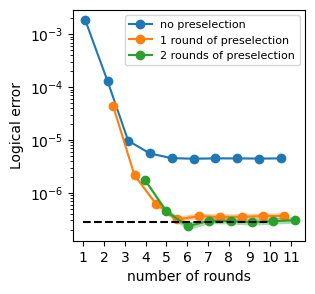

In [13]:
plt.figure(figsize=(3, 3))         

# loop through preselected rounds
for preselect in preselect_list:
    # logical error
    if preselect == 0:
        plt.plot(mean_rounds_list[:,preselect],Logical_Error[preselect],'-o',label = f'no preselection')
    elif preselect == 1:
        plt.plot(mean_rounds_list[:,preselect],Logical_Error[preselect],'-o',label = f'1 round of preselection')
    else:
        plt.plot(mean_rounds_list[:,preselect],Logical_Error[preselect],'-o',label = f'{preselect} rounds of preselection')
    # error bar
    plt.fill_between(mean_rounds_list[:,preselect],Logical_Error[preselect] - Logical_Error_u[preselect],
                     Logical_Error[preselect] + Logical_Error_u[preselect], alpha=0.4)
    
# theoritcal 35p^3 of distillation
plt.plot([rounds_list[0],rounds_list[-1]],[35*(2/3*1e-3 + 1e-3 + 1e-3/3)**3]*2,'--',c='k')

plt.legend(loc = 'upper right',fontsize = 8)
plt.yscale('log')
plt.xlabel('number of rounds')
plt.ylabel('Logical error')

ax = plt.gca()                
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.NullLocator())

In [19]:
import pandas as pd
column_names = [f"{i} min rounds" for i in range(1,11)]
row_names = [f"preselection {i} round(s)" for i in range(3)]
df = pd.DataFrame(Logical_Error, columns=column_names, index=row_names)
df

,1 min rounds,2 min rounds,3 min rounds,4 min rounds,5 min rounds,6 min rounds,7 min rounds,8 min rounds,9 min rounds,10 min rounds
preselection 0 round(s),0.00185,0.000129,0.000010,5.562126e-06,4.540387e-06,4.433114e-06,4.494037e-06,4.489782e-06,4.463511e-06,4.488791e-06
preselection 1 round(s),NaN,0.000044,0.000002,6.247442e-07,3.136649e-07,3.622213e-07,3.504155e-07,3.530309e-07,3.622132e-07,3.661522e-07
preselection 2 round(s),NaN,NaN,0.000002,4.456233e-07,2.334950e-07,2.965728e-07,2.934089e-07,2.796743e-07,2.918694e-07,3.042551e-07
